# LSTM vs Transformer - Sequential Next-Latent Prediction

Uses the best AE checkpoint (500 episodes, early stopping) and trains both models on the same data for a head-to-head comparison.

## Setup

In [1]:
from pathlib import Path
from datetime import datetime
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

_cwd = Path.cwd().resolve()
STUDENT = None
for p in [_cwd, *_cwd.parents]:
    if (p / "src").is_dir() and (p / "notebooks").is_dir() and (p / "data").is_dir():
        STUDENT = p
        break
if STUDENT is None:
    raise RuntimeError("Could not find Student root")

FRAMES_ROOT = STUDENT / "data" / "frames"
RUNS_ROOT = STUDENT / "runs"

# Use the best AE: 500 episodes, early stopping
AE_RUN_DIR = RUNS_ROOT / "autoencoder" / "autoencoder_28042026_222428"
assert (AE_RUN_DIR / "model.pth").exists(), f"AE checkpoint not found: {AE_RUN_DIR}"

stamp = datetime.now().strftime("%d%m%Y_%H%M%S")
RUN_DIR = RUNS_ROOT / "sequential" / f"comparison_{stamp}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("AE:", AE_RUN_DIR.name)
print("Run dir:", RUN_DIR.name)

Device: mps
AE: autoencoder_28042026_222428
Run dir: comparison_28042026_225618


## Load Autoencoder

In [2]:
Z_DIM = 64

class AutoEncoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(25600, z_dim),
            nn.LayerNorm(z_dim),
        )
        self.decoder_fc = nn.Linear(z_dim, 25600)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1), nn.Sigmoid(),
        )
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder_fc(z).view(-1, 256, 10, 10)
        x_hat = self.decoder(x_hat)
        return x_hat[:, :, :84, :84], z
    def decode(self, z):
        x_hat = self.decoder_fc(z).view(-1, 256, 10, 10)
        x_hat = self.decoder(x_hat)
        return x_hat[:, :, :84, :84]

ae_model = AutoEncoder(z_dim=Z_DIM).to(DEVICE)
ae_model.load_state_dict(torch.load(AE_RUN_DIR / "model.pth", map_location=DEVICE))
ae_model.eval()
for p in ae_model.parameters():
    p.requires_grad = False
print("AE loaded (test loss: 0.011389)")

AE loaded (test loss: 0.011389)


## Build Sequential Dataset

Build from all 500 episodes with the good AE.

In [3]:
SEQ_LEN = 32
TEST_RATIO = 0.2
SEED = 42

def sim_func(prev, curr, threshold=0.01):
    prev_v = prev.reshape(-1).astype(np.float32)
    curr_v = curr.reshape(-1).astype(np.float32)
    alpha = np.dot(curr_v, prev_v) / (np.dot(prev_v, prev_v) + 1e-8)
    residual = curr_v - alpha * prev_v
    return np.linalg.norm(residual) / (np.linalg.norm(curr_v) + 1e-8) > threshold

video_dirs = sorted([p for p in FRAMES_ROOT.iterdir() if p.is_dir()], key=lambda p: int(p.name))
print(f"Episodes: {len(video_dirs)}")

# Load and reduce frames
episodes = []
for vd in video_dirs:
    frames = sorted(vd.glob("*.png"), key=lambda p: int(p.stem))
    if not frames:
        episodes.append(np.empty((0, 84, 84), dtype=np.float32))
        continue
    xs = np.stack([np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0 for p in frames])
    curr = xs[0]
    kept = [curr]
    for j in range(1, len(xs)):
        if sim_func(curr, xs[j]):
            curr = xs[j]
            kept.append(curr)
    episodes.append(np.stack(kept))

# Chunk into sequences
chunks, chunk_lengths, ep_ids = [], [], []
for ep_idx, ep in enumerate(episodes):
    t = len(ep)
    if t == 0:
        continue
    tensor = torch.tensor(ep, dtype=torch.float32).unsqueeze(1)
    for start in range(0, t, SEQ_LEN):
        chunk = tensor[start:start + SEQ_LEN]
        valid = chunk.shape[0]
        if valid < SEQ_LEN:
            pad = torch.zeros((SEQ_LEN - valid, 1, 84, 84))
            chunk = torch.cat([chunk, pad])
        chunks.append(chunk)
        chunk_lengths.append(valid)
        ep_ids.append(ep_idx)

x = torch.stack(chunks)
lengths = torch.tensor(chunk_lengths, dtype=torch.int32)
ep_ids_t = torch.tensor(ep_ids, dtype=torch.int32)

# Train/test split by episode
rng = np.random.default_rng(SEED)
all_eps = np.arange(len(episodes))
rng.shuffle(all_eps)
n_test = int(np.ceil(TEST_RATIO * len(episodes)))
test_eps = set(all_eps[:n_test].tolist())
train_mask = torch.tensor([int(e.item()) not in test_eps for e in ep_ids_t])
test_mask = ~train_mask

train_dataset = TensorDataset(x[train_mask], lengths[train_mask], ep_ids_t[train_mask])
test_dataset = TensorDataset(x[test_mask], lengths[test_mask], ep_ids_t[test_mask])

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=BATCH_SIZE)

print(f"Train: {len(train_dataset)} chunks, Test: {len(test_dataset)} chunks")

Episodes: 500


Train: 3044 chunks, Test: 776 chunks


## Models

In [4]:
class LatentLSTM(nn.Module):
    def __init__(self, z_dim, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=z_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, z_dim))

    def forward(self, z_seq, lengths=None):
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                z_seq, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, (h_n, _) = self.lstm(packed)
        else:
            _, (h_n, _) = self.lstm(z_seq)
        return self.head(h_n[-1])

class LatentTransformer(nn.Module):
    def __init__(self, z_dim, hidden_dim=256, num_layers=2, n_heads=4, dropout=0.1, max_seq_len=128):
        super().__init__()
        self.input_proj = nn.Linear(z_dim, hidden_dim)
        self.pos_embed = nn.Embedding(max_seq_len, hidden_dim)
        layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads,
            dim_feedforward=hidden_dim * 4, dropout=dropout, activation="gelu", batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, z_dim))

    def forward(self, z_seq, lengths=None):
        B, T, _ = z_seq.shape
        device = z_seq.device
        x = self.input_proj(z_seq) + self.pos_embed(torch.arange(T, device=device).unsqueeze(0))
        causal = nn.Transformer.generate_square_subsequent_mask(T, device=device, dtype=x.dtype)
        pad_mask = None
        if lengths is not None:
            bm = torch.arange(T, device=device).unsqueeze(0) >= lengths.unsqueeze(1)
            pad_mask = torch.zeros_like(bm, dtype=x.dtype).masked_fill(bm, float("-inf"))
        x = self.transformer(x, mask=causal, src_key_padding_mask=pad_mask)
        if lengths is not None:
            idx = (lengths - 1).clamp(min=0).long()
        else:
            idx = torch.full((B,), T - 1, dtype=torch.long, device=device)
        return self.head(x[torch.arange(B, device=device), idx])

lstm_params = sum(p.numel() for p in LatentLSTM(Z_DIM).parameters())
tf_params = sum(p.numel() for p in LatentTransformer(Z_DIM, max_seq_len=SEQ_LEN).parameters())
print(f"LSTM: {lstm_params:,} params | Transformer: {tf_params:,} params")

LSTM: 938,816 params | Transformer: 1,687,104 params


## Train Both

In [5]:
EPOCHS = 30
LR = 3e-4
GRAD_CLIP = 1.0

def train_model(model, name):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    train_losses, test_losses = [], []
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        ep_loss, n_b = 0.0, 0

        for batch in train_loader:
            bx, blens = batch[0].to(DEVICE), batch[1].to(DEVICE)
            z_in, z_tgt = [], []
            with torch.no_grad():
                for i in range(bx.shape[0]):
                    sl = int(blens[i].item())
                    if sl < 2: continue
                    xv = bx[i:i+1, :sl]
                    zl = [ae_model(xv[:, t])[1] for t in range(sl - 1)]
                    z_in.append(torch.stack(zl, dim=1).squeeze(0))
                    z_tgt.append(ae_model(xv[:, -1])[1].squeeze(0))
            if not z_in: continue

            il = torch.tensor([z.shape[0] for z in z_in], dtype=torch.int64, device=DEVICE)
            ml = int(il.max().item())
            padded = [torch.cat([z, torch.zeros(ml - z.shape[0], z.shape[1], device=DEVICE)]) if z.shape[0] < ml else z for z in z_in]

            pred = model(torch.stack(padded), lengths=il)
            loss = F.mse_loss(pred, torch.stack(z_tgt))
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            ep_loss += loss.item()
            n_b += 1

        # Test loss
        model.eval()
        test_loss, test_nb = 0.0, 0
        with torch.no_grad():
            for batch in test_loader:
                bx, blens = batch[0].to(DEVICE), batch[1].to(DEVICE)
                z_in, z_tgt = [], []
                for i in range(bx.shape[0]):
                    sl = int(blens[i].item())
                    if sl < 2: continue
                    xv = bx[i:i+1, :sl]
                    zl = [ae_model(xv[:, t])[1] for t in range(sl - 1)]
                    z_in.append(torch.stack(zl, dim=1).squeeze(0))
                    z_tgt.append(ae_model(xv[:, -1])[1].squeeze(0))
                if not z_in: continue
                il = torch.tensor([z.shape[0] for z in z_in], dtype=torch.int64, device=DEVICE)
                ml = int(il.max().item())
                padded = [torch.cat([z, torch.zeros(ml - z.shape[0], z.shape[1], device=DEVICE)]) if z.shape[0] < ml else z for z in z_in]
                pred = model(torch.stack(padded), lengths=il)
                test_loss += F.mse_loss(pred, torch.stack(z_tgt)).item()
                test_nb += 1

        tr_mean = ep_loss / max(n_b, 1)
        te_mean = test_loss / max(test_nb, 1)
        train_losses.append(tr_mean)
        test_losses.append(te_mean)
        print(f"[{name}] epoch {epoch:03d}/{EPOCHS} train {tr_mean:.6f} test {te_mean:.6f} | {time.time()-t0:.1f}s")

    return train_losses, test_losses

# Train LSTM
print("=" * 50)
print("  LSTM")
print("=" * 50)
lstm_model = LatentLSTM(Z_DIM).to(DEVICE)
lstm_train, lstm_test = train_model(lstm_model, "LSTM")

# Train Transformer
print()
print("=" * 50)
print("  TRANSFORMER")
print("=" * 50)
tf_model = LatentTransformer(Z_DIM, max_seq_len=SEQ_LEN).to(DEVICE)
tf_train, tf_test = train_model(tf_model, "TF")

  LSTM


[LSTM] epoch 001/30 train 0.242912 test 0.048184 | 102.7s


[LSTM] epoch 002/30 train 0.058295 test 0.023413 | 211.6s


[LSTM] epoch 003/30 train 0.039620 test 0.015748 | 329.8s


[LSTM] epoch 004/30 train 0.032274 test 0.012537 | 436.7s


...

[TF] epoch 026/30 train 0.014654 test 0.004858 | 3337.4s


[TF] epoch 027/30 train 0.014100 test 0.005081 | 3452.1s


[TF] epoch 028/30 train 0.014104 test 0.005745 | 3559.0s


[TF] epoch 029/30 train 0.014149 test 0.005668 | 3665.3s


[TF] epoch 030/30 train 0.013786 test 0.004827 | 3763.1s


## Comparison

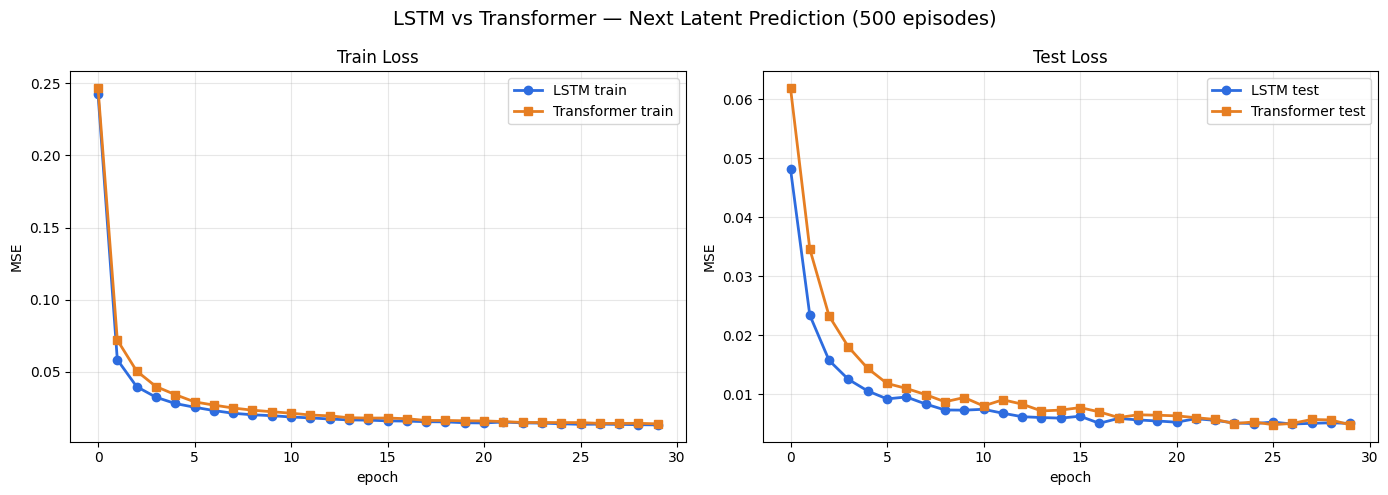

LSTM  - final train: 0.013058, final test: 0.005076
TF    - final train: 0.013786, final test: 0.004827


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_train, 'o-', lw=2, label="LSTM train", color="#2d6cdf")
axes[0].plot(tf_train, 's-', lw=2, label="Transformer train", color="#e67e22")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lstm_test, 'o-', lw=2, label="LSTM test", color="#2d6cdf")
axes[1].plot(tf_test, 's-', lw=2, label="Transformer test", color="#e67e22")
axes[1].set_title("Test Loss")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("MSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("LSTM vs Transformer - Next Latent Prediction (500 episodes)", fontsize=14)
plt.tight_layout()
plt.savefig(RUN_DIR / "comparison_loss.png", dpi=150)
plt.show()

print(f"LSTM  - final train: {lstm_train[-1]:.6f}, final test: {lstm_test[-1]:.6f}")
print(f"TF    - final train: {tf_train[-1]:.6f}, final test: {tf_test[-1]:.6f}")

## Save

In [7]:
torch.save(lstm_model.state_dict(), RUN_DIR / "lstm_model.pth")
torch.save(tf_model.state_dict(), RUN_DIR / "tf_model.pth")
torch.save({
    "lstm_train": lstm_train, "lstm_test": lstm_test,
    "tf_train": tf_train, "tf_test": tf_test,
}, RUN_DIR / "losses.pt")
print(f"Saved to {RUN_DIR}")

Saved to /Users/sebastiannickels/Projects/Personal/video-to-policy/Student/runs/sequential/comparison_28042026_225618
